# Network Intrusion Detection System (NIDS)
1. Load and explore the data
2. EDA with 8 charts
3. Preprocessing
4. Feature Engineering
5. Train models (Random Forest + Logistic Regression)
6. Evaluate results

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## Step 2: Load the Data

In [2]:
train = pd.read_csv('archive/UNSW_NB15_training-set.csv')
test  = pd.read_csv('archive/UNSW_NB15_testing-set.csv')

train.shape
test.shape

(175341, 45)

## Step 3: Quick Data Overview

In [3]:
train.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [4]:
train.dtypes

id                     int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_l

In [5]:
missing = train.isnull().sum()


In [6]:
train.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,41166.500000,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,...,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,23767.345519,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,...,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20583.750000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,41166.500000,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,61749.250000,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,82332.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,...,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


## Step 4: Exploratory Data Analysis (EDA)



### Chart 1: Normal vs Attack (Label Distribution)

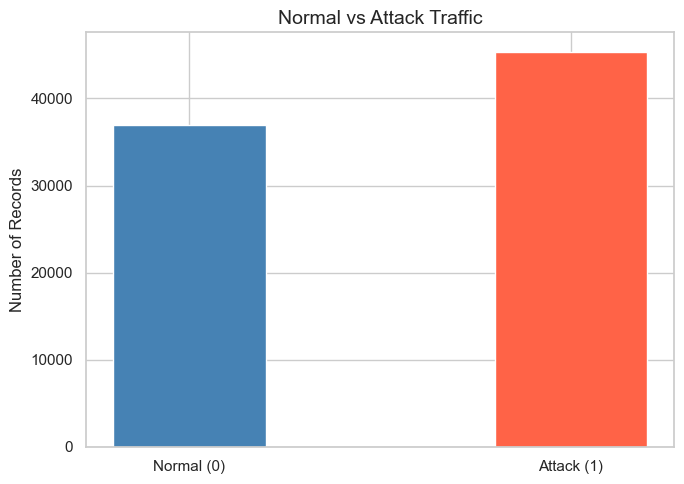

In [7]:
label_counts = train['label'].value_counts().sort_index()
plt.figure(figsize=(7, 5))
bars = plt.bar(['Normal (0)', 'Attack (1)'], label_counts.values,color=['steelblue', 'tomato'], width=0.4)
plt.title('Normal vs Attack Traffic', fontsize=14)
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

### Chart 2: Attack Category Distribution

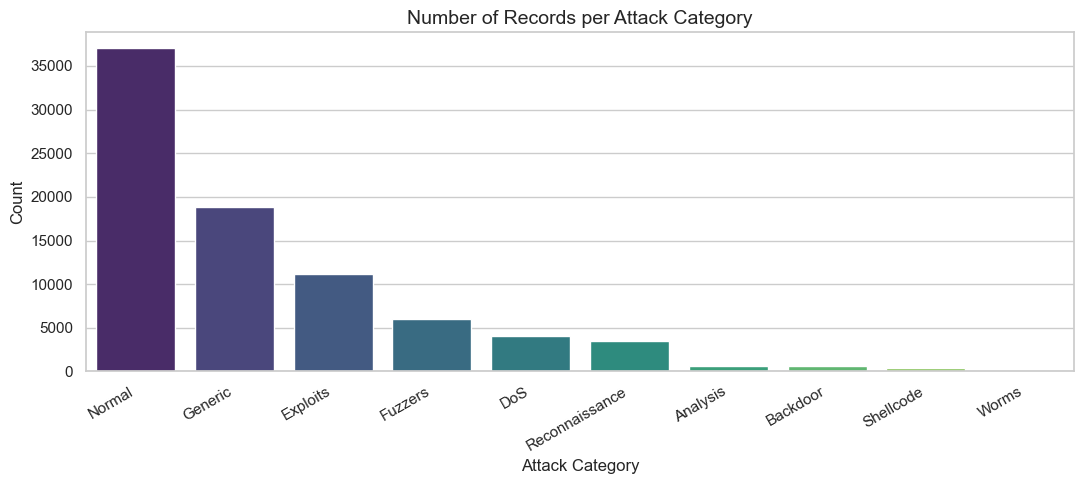

In [8]:
attack_counts = train['attack_cat'].value_counts()
plt.figure(figsize=(11, 5))
sns.barplot(x=attack_counts.index, y=attack_counts.values, palette='viridis')
plt.title('Number of Records per Attack Category', fontsize=14)
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Chart 3: Protocol Distribution

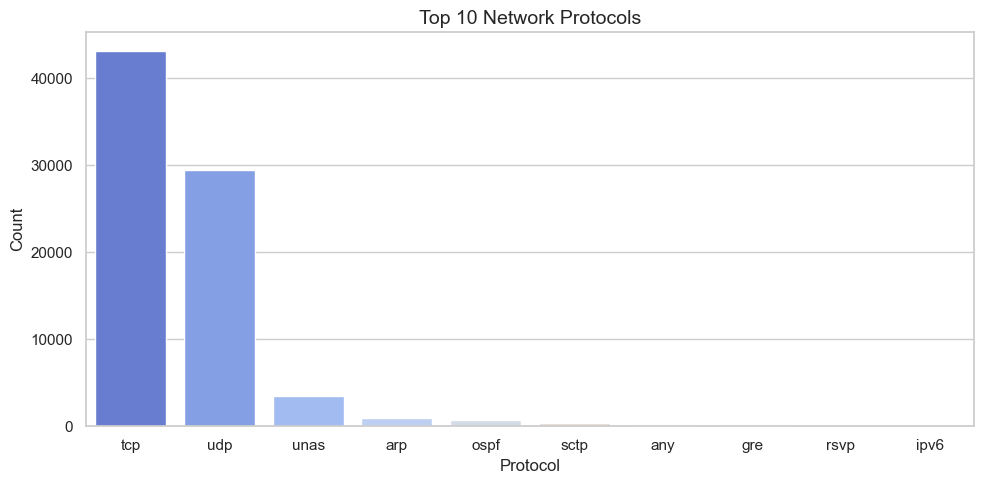

In [9]:
top_protos = train['proto'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_protos.index, y=top_protos.values, palette='coolwarm')
plt.title('Top 10 Network Protocols', fontsize=14)
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Chart 4: Service Distribution

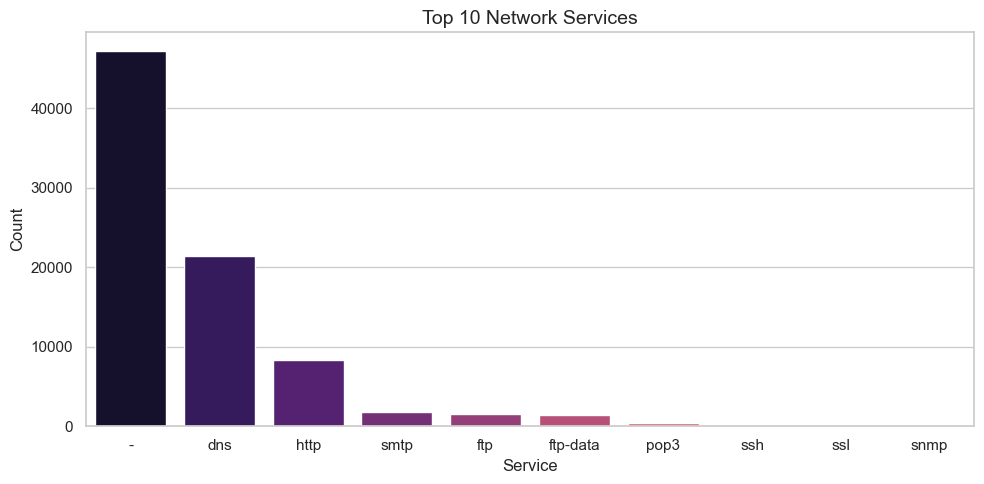

In [10]:
top_services = train['service'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_services.index, y=top_services.values, palette='magma')
plt.title('Top 10 Network Services', fontsize=14)
plt.xlabel('Service')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Chart 5: Packet Count Distribution (Source vs Destination)

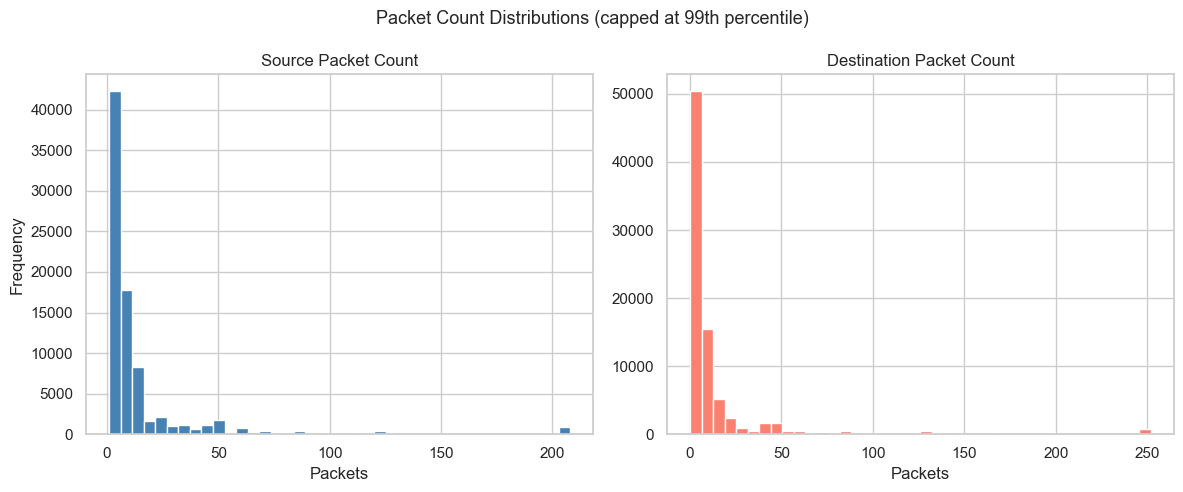

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
spkts_cap = train['spkts'].clip(upper=train['spkts'].quantile(0.99))
dpkts_cap = train['dpkts'].clip(upper=train['dpkts'].quantile(0.99))
axes[0].hist(spkts_cap, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Source Packet Count')
axes[0].set_xlabel('Packets')
axes[0].set_ylabel('Frequency')
axes[1].hist(dpkts_cap, bins=40, color='salmon', edgecolor='white')
axes[1].set_title('Destination Packet Count')
axes[1].set_xlabel('Packets')
plt.suptitle('Packet Count Distributions (capped at 99th percentile)', fontsize=13)
plt.tight_layout()
plt.show()

### Chart 6: Connection Duration: Normal vs Attack

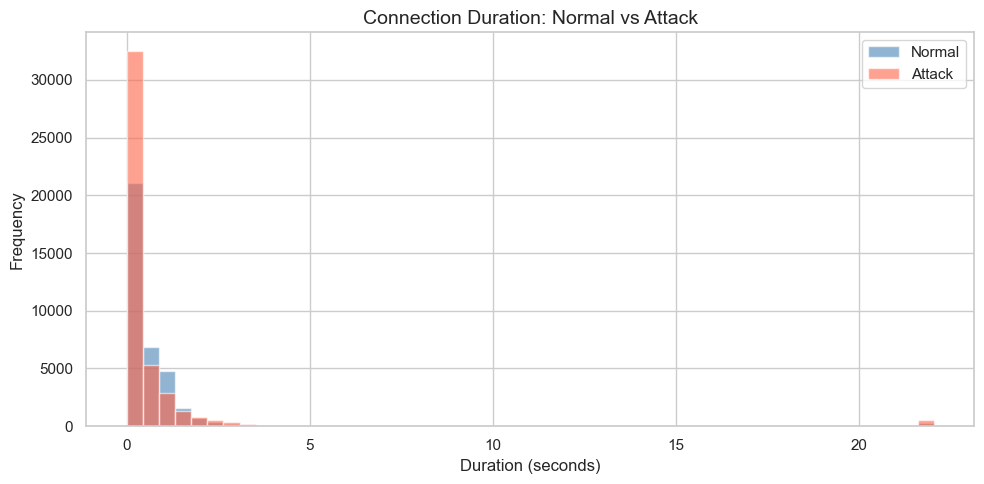

In [12]:
dur_cap = train['dur'].clip(upper=train['dur'].quantile(0.99))
plt.figure(figsize=(10, 5))
plt.hist(dur_cap[train['label'] == 0], bins=50, alpha=0.6, color='steelblue', label='Normal')
plt.hist(dur_cap[train['label'] == 1], bins=50, alpha=0.6, color='tomato',    label='Attack')
plt.title('Connection Duration: Normal vs Attack', fontsize=14)
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

### Chart 7: Correlation Heatmap

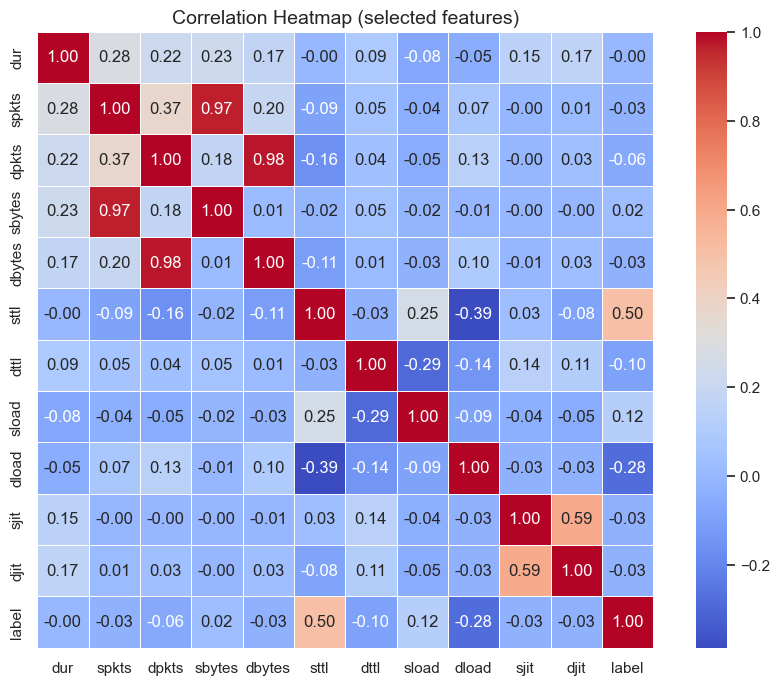

In [13]:
numeric_cols = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sload', 'dload', 'sjit', 'djit', 'label']
corr = train[numeric_cols].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',linewidths=0.5, square=True)
plt.title('Correlation Heatmap (selected features)', fontsize=14)
plt.show()

### Chart 8: Source Bytes vs Destination Bytes (coloured by label)

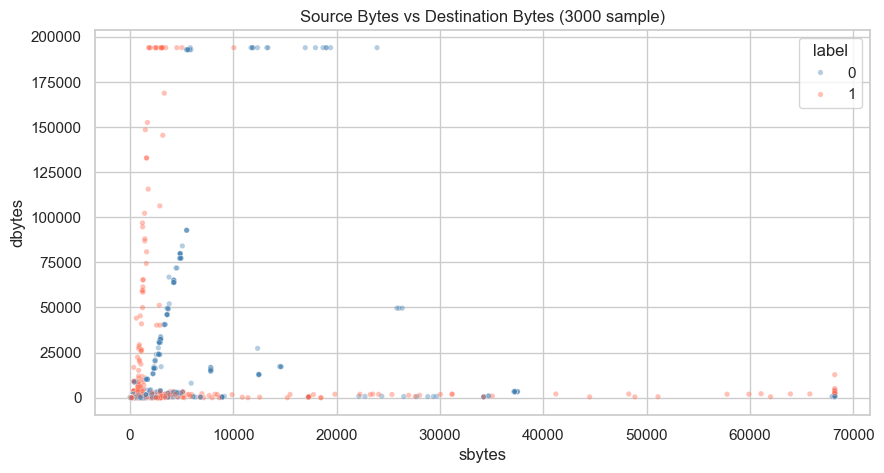

In [14]:
sample = train.sample(3000, random_state=42)
sns.scatterplot(data=sample,x=sample['sbytes'].clip(upper=sample['sbytes'].quantile(0.99)),
    y=sample['dbytes'].clip(upper=sample['dbytes'].quantile(0.99)),
    hue='label', palette={0: 'steelblue', 1: 'tomato'}, alpha=0.4, s=15
)
plt.title('Source Bytes vs Destination Bytes (3000 sample)')
plt.show()


## Step 5: Preprocessing


In [15]:
df_train = train.copy()
df_test  = test.copy()
df_train.drop(columns=['id', 'attack_cat'], inplace=True) # 'id' is just a row number, not useful for the model
df_test.drop(columns=['id', 'attack_cat'],  inplace=True) # 'attack_cat' leaks the answer (label is our actual target)
print('Columns after dropping:', df_train.shape[1])

Columns after dropping: 43


In [16]:
text_cols = df_train.select_dtypes(include='object').columns.tolist()
print('Text columns to encode:', text_cols)

Text columns to encode: ['proto', 'service', 'state']


In [17]:
# LabelEncoder converts each unique text value to an integer
# e.g. 'tcp' -> 0, 'udp' -> 1
le = LabelEncoder()

for col in text_cols:
    df_train[col] = le.fit_transform(df_train[col].astype(str))
    known = list(le.classes_)
    df_test[col] = df_test[col].astype(str).apply(
        lambda x: le.transform([x])[0] if x in known else -1
    )
print('Encoding done!')

Encoding done!


In [18]:
X_train = df_train.drop(columns=['label'])
y_train = df_train['label']
X_test = df_test.drop(columns=['label'])
y_test = df_test['label']
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (82332, 42)
X_test : (175341, 42)


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling done!')

Scaling done!


## Step 6: Feature Engineering

In [20]:
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

# total traffic = source + destination bytes
X_train['total_bytes'] = X_train['sbytes'] + X_train['dbytes']
X_test['total_bytes']  = X_test['sbytes']  + X_test['dbytes']

# total packets
X_train['total_pkts'] = X_train['spkts'] + X_train['dpkts']
X_test['total_pkts']  = X_test['spkts']  + X_test['dpkts']

# average bytes per packet
X_train['bytes_per_pkt'] = X_train['total_bytes'] / (X_train['total_pkts'] + 1e-6)
X_test['bytes_per_pkt']  = X_test['total_bytes']  / (X_test['total_pkts']  + 1e-6)

# TTL difference between source and destination
X_train['ttl_diff'] = abs(X_train['sttl'] - X_train['dttl'])
X_test['ttl_diff']  = abs(X_test['sttl']  - X_test['dttl'])


## Step 7:  Train Models

In [21]:
print('Training Random Forest')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)


Training Random Forest


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
print('Training Logistic Regression')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)


Training Logistic Regression


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Step 8: Evaluate the Models

In [23]:
rf_preds = rf.predict(X_test)
lr_preds = lr.predict(X_test)

print('Random Forest Accuracy:', round(accuracy_score(y_test, rf_preds) * 100, 2),'%')
print('Logistic Regression Accuracy:', round(accuracy_score(y_test, lr_preds) * 100, 2),'%')

Random Forest Accuracy: 90.31 %
Logistic Regression Accuracy: 87.34 %


In [24]:
print('=== Random Forest ===' )
print(classification_report(y_test, rf_preds, target_names=['Normal', 'Attack']))

=== Random Forest ===
              precision    recall  f1-score   support

      Normal       0.78      0.98      0.87     56000
      Attack       0.99      0.87      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.90    175341
weighted avg       0.92      0.90      0.91    175341



In [25]:
print('=== Logistic Regression ===')
print(classification_report(y_test, lr_preds, target_names=['Normal', 'Attack']))

=== Logistic Regression ===
              precision    recall  f1-score   support

      Normal       0.74      0.94      0.83     56000
      Attack       0.97      0.84      0.90    119341

    accuracy                           0.87    175341
   macro avg       0.85      0.89      0.86    175341
weighted avg       0.89      0.87      0.88    175341



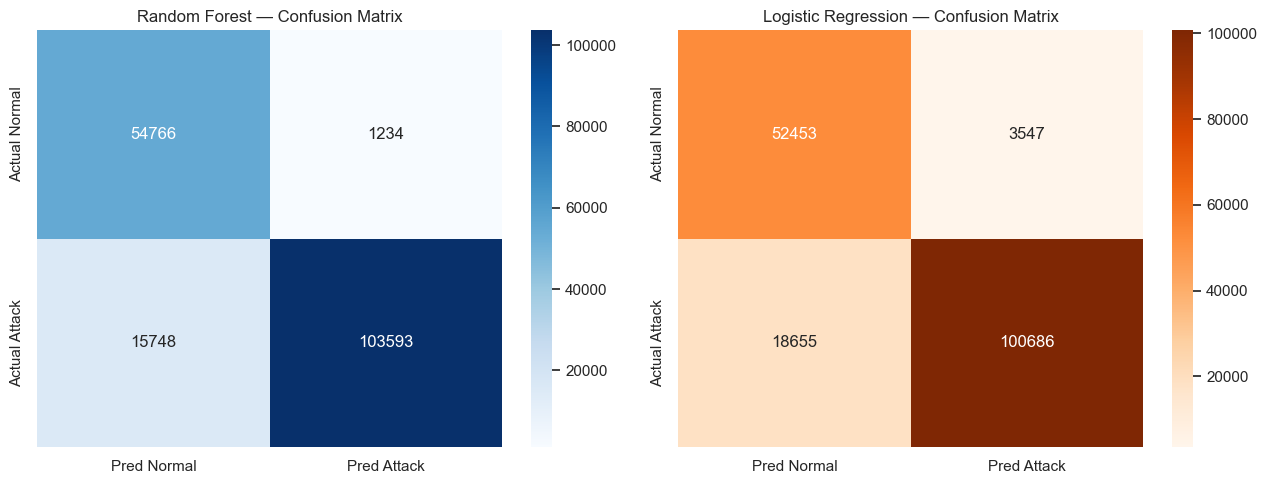

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, title, cmap in zip(
    axes,
    [rf_preds, lr_preds],
    ['Random Forest', 'Logistic Regression'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Pred Normal', 'Pred Attack'],
                yticklabels=['Actual Normal', 'Actual Attack'])
    ax.set_title(title + ' — Confusion Matrix', fontsize=12)

plt.tight_layout()
plt.show()

## Step 9: Feature Importance (Random Forest)

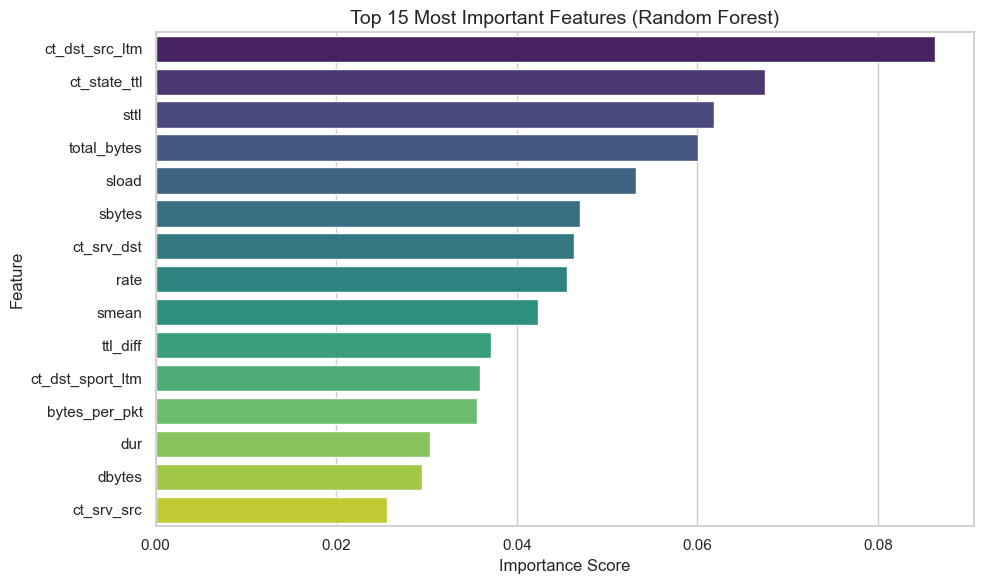

In [27]:
feat_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': rf.feature_importances_
})
feat_df = feat_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_df, palette='viridis')
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()